# Credit Default Risk Classifier

*Librerias*

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

## Obtener el set de datos

*Cargar dataset*

In [123]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CS AVANZADAS/Modulo Inteligencia Artificial/Proyecto/Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv",)

In [124]:
df.head()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


*Revisando los datatypes*

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score         

*Determinar missing values en cada variable*

In [126]:
df.count()

,0
user_id,10345
age,10345
employment_type,10345
monthly_income,10345
credit_score,10345
purchase_amount,10345
product_category,10345
bnpl_installments,10345
repayment_delay_days,10345
missed_payments,10345


In [127]:
print('Columns with null values:', df.isnull().sum(), sep = '\n')

Columns with null values:
user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64


\
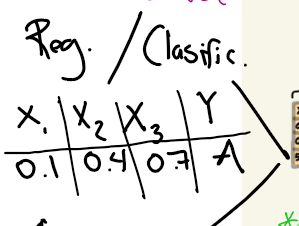

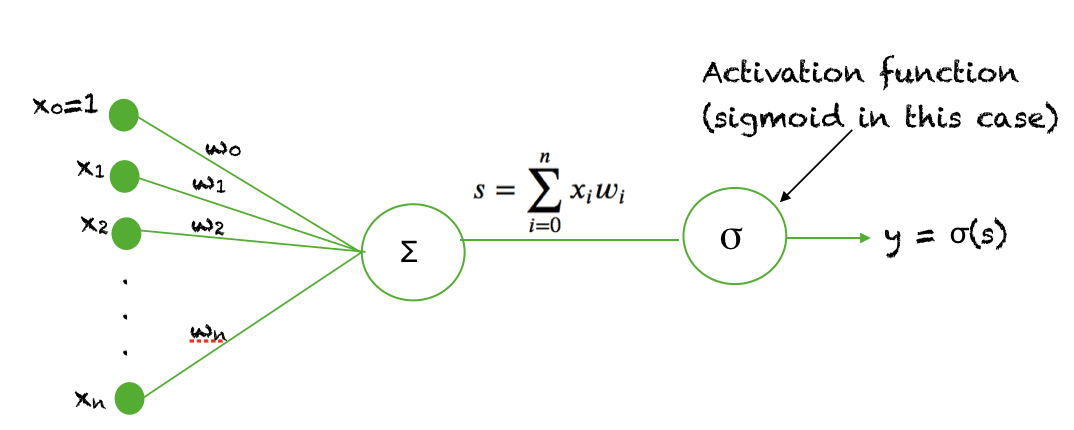

*Limpiar datos: Seleccionar columnas necesarias para determinar features (x) y target (y) y enfocarlo como un modelo de clasificación, usando una regresión logistica (función sigmoid)*


### Selección de Features

*Para elegir sabiamente las features, me parecio interesante probar con una Correlación de Pearson para determinar que tan revelantes son unas variables sobre otras en función de `default_flag`*

In [128]:
corr_target = df.select_dtypes(include=np.number) \
                .corr()['default_flag'] \
                .drop('default_flag') \
                .abs() \
                .sort_values(ascending=False)

print("Correlación absoluta con default_flag:")
print(corr_target.round(4))

Correlación absoluta con default_flag:
risk_score              0.3994
credit_score            0.3242
repayment_delay_days    0.2832
monthly_income          0.2742
missed_payments         0.2723
debt_to_income_ratio    0.1729
purchase_amount         0.0979
age                     0.0757
user_id                 0.0192
bnpl_installments       0.0122
app_usage_frequency     0.0039
Name: default_flag, dtype: float64


#### Correlación de Pearson

Se calculó la correlación de Pearson entre cada feature numérica y `default_flag`,
que mide la fuerza de la relación lineal entre dos variables:

$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2} \cdot \sqrt{\sum(y_i - \bar{y})^2}}$$

Se usó el valor absoluto $|r|$ para evaluar magnitud
sin importar dirección, y se estableció un umbral mínimo de $|r| \geq 0.10$.
Las features en verde brillante superan el umbral y fueron seleccionadas. Las verdes atenuadas fueron descartadas.

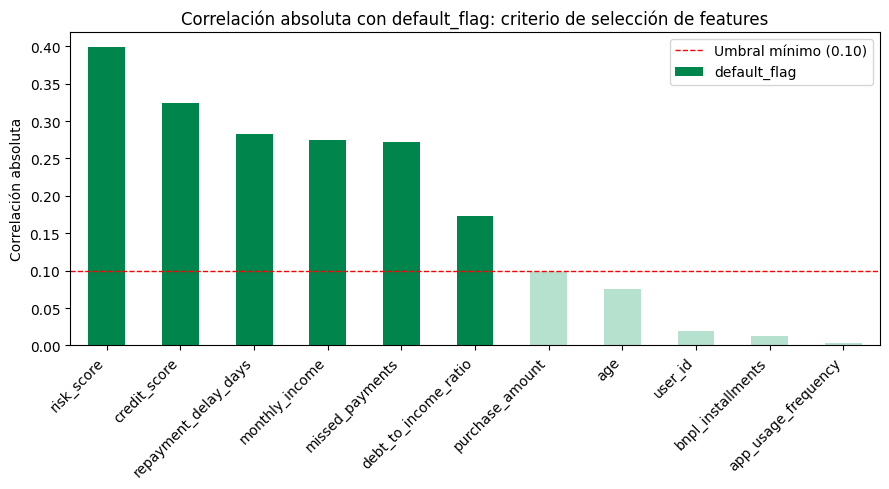

In [129]:
plt.figure(figsize=(9, 5))
colors = ['#00864d' if col in ['risk_score', 'credit_score',
          'repayment_delay_days', 'monthly_income', 'missed_payments', 'debt_to_income_ratio']
          else '#b5e1ce' for col in corr_target.index]

corr_target.plot(kind='bar', color=colors)
plt.axhline(0.10, color='red', linestyle='--', linewidth=1, label='Umbral mínimo (0.10)')
plt.title('Correlación absoluta con default_flag: criterio de selección de features')
plt.ylabel('Correlación absoluta')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [130]:
x_values = df[['risk_score', 'credit_score', 'repayment_delay_days', 'monthly_income', 'missed_payments', 'debt_to_income_ratio']]

In [131]:
x_values

,risk_score,credit_score,repayment_delay_days,monthly_income,missed_payments,debt_to_income_ratio
0,165.2,552,13,68529.50,1,0.072961
1,266.0,300,13,7247.85,1,0.148076
2,229.6,471,19,41582.26,2,0.120244
3,356.0,300,18,14423.46,5,0.282653
4,135.2,512,0,42845.50,0,0.116698
...,...,...,...,...,...,...
10340,182.8,393,0,17344.34,0,0.288278
10341,264.0,300,12,17788.20,1,0.005622
10342,174.0,535,4,59350.25,2,0.084246
10343,72.8,678,2,73739.74,0,0.067806


In [132]:
y_target = df['default_flag']

In [133]:
y_target

,default_flag
0,0
1,0
2,0
3,1
4,0
...,...
10340,1
10341,0
10342,0
10343,0


*Como mi target ya esta en binario, no considero necesario realizar el Label Encoder*

## Split de train y test set

In [134]:
n_samples = len(x_values)
shuffled_indices = np.random.permutation(n_samples)
test_size = int(0.20 * n_samples)

In [135]:
# Sacar indices para test y train
test_indices = shuffled_indices[:test_size]
train_indices = shuffled_indices[test_size:]

# Split de data usando los indices generados
X_train = x_values.iloc[train_indices]
X_test = x_values.iloc[test_indices]
y_train = y_target.iloc[train_indices]
y_test = y_target.iloc[test_indices]

print(f"Tamaño del set de entrenamiento (X): {X_train.shape}")
print(f"Tamaño del set de prueba (X): {X_test.shape}")
print(f"Tamaño del set de entrenamiento (y): {y_train.shape}")
print(f"Tamaño del set de prueba (y): {y_test.shape}")

Tamaño del set de entrenamiento (X): (8276, 6)
Tamaño del set de prueba (X): (2069, 6)
Tamaño del set de entrenamiento (y): (8276,)
Tamaño del set de prueba (y): (2069,)


## Preprocesado de datos

### Técnica de escalamiento

*Realizar un escalamiento de las features ya que hay algunas que tienen valores muy altas y puede causar sesgos*

*Tecnica: Standardization*

$$z = \frac{x - \mu}{\sigma}$$

Donde μ es la media y σ es la desviación estándar. El resultado es que cada valor queda expresado en terminos de cuántas desviaciones estándar está alejado de la media

In [136]:
X_train_arr = X_train.values.astype(np.float32)
X_test_arr = X_test.values.astype(np.float32)

# Calcular media y std solo para train
mean = X_train_arr.mean(axis=0)
std = X_train_arr.std(axis=0)

# Aplicar a ambos
X_train_scaled = (X_train_arr - mean) / std
X_test_scaled  = (X_test_arr  - mean) / std  # usa la media/std del train


In [137]:
X_train_scaled

array([[ 1.5012552 , -1.0843856 ,  0.1903307 , -0.71460277,  2.0012608 ,
         1.1058632 ],
       [ 0.5701096 , -0.5515665 ,  0.6318866 , -0.37117207, -0.00594209,
        -0.1643656 ],
       [-1.3511149 ,  1.1709722 , -0.5455958 ,  0.61426467, -1.0095435 ,
        -0.6753794 ],
       ...,
       [-1.0977019 ,  1.6964926 , -0.10403991,  1.6696569 ,  0.9976593 ,
        -0.9504907 ],
       [ 0.652616  ,  0.22211617,  1.2206278 ,  0.83459455,  2.0012608 ,
        -0.75538516],
       [-0.31978282,  1.5359169 ,  1.6621838 ,  1.9391981 ,  2.0012608 ,
        -0.99192613]], dtype=float32)

## Implementación del modelo

### Modelo seleccionado: Multilayer Perceptron (MLP)

Para implementar el modelo decidí una **Red Neuronal Feedforward (MLP)**.

La arquitectura que considero implementar consiste en dos capas ocultas con activación **ReLU**
y una capa de salida con activación **Sigmoid**, que produce una probabilidad de default entre 0 y 1.

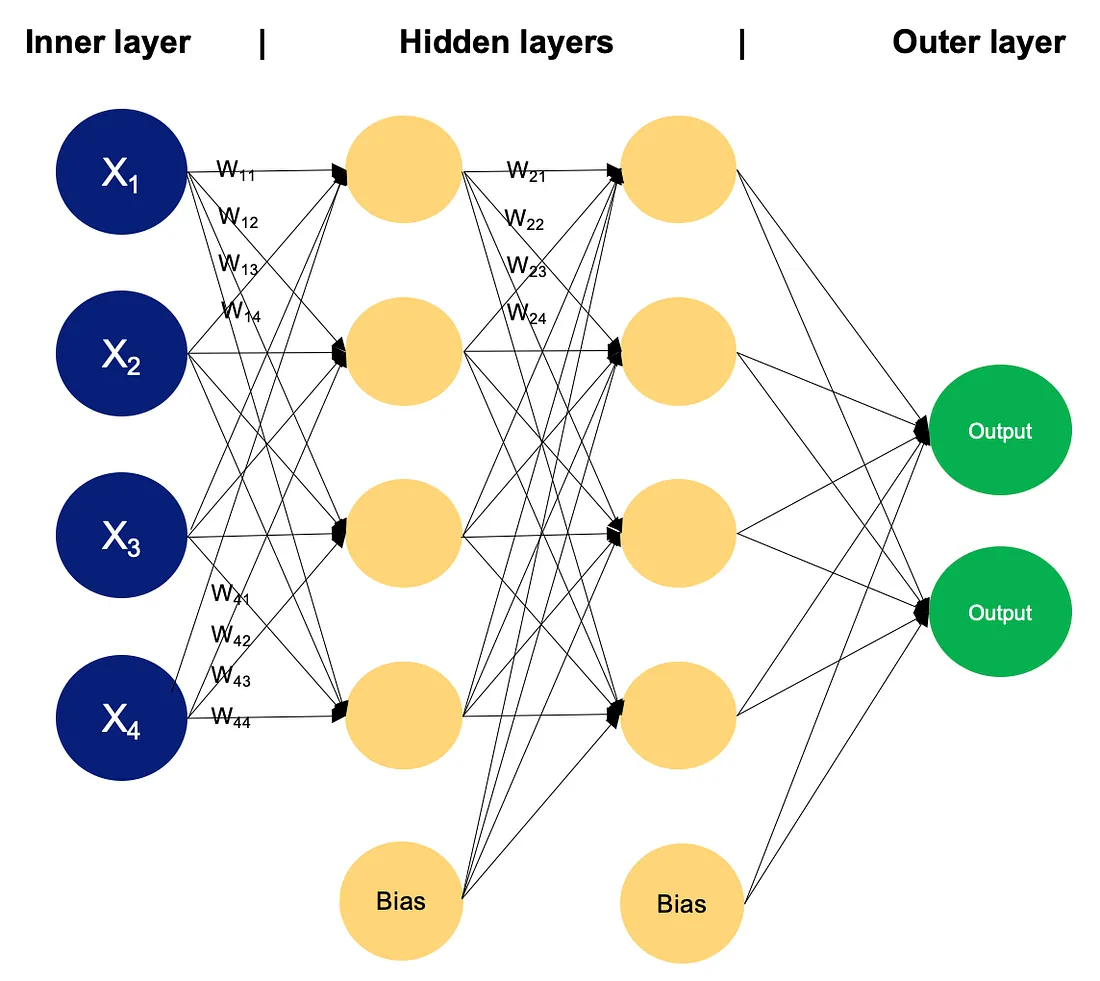

La elección de este
modelo está respaldada por Yakubu et al. (2025), quienes demuestran que una
arquitectura MLP relativamente simple, cuando se combina con estandarización
de datos mediante Z-score, puede superar modelos más complejos como Deep Neural
Networks (DNNs), obteniendo mejoras sustanciales en métricas críticas como
Recall y F1-Score.

In [138]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1,  activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

*Entrenar el modelo*

In [139]:
y_train_arr = y_train.values.astype(np.float32)
y_test_arr = y_test.values.astype(np.float32)

history = model.fit(
    X_train_scaled, y_train_arr,
    epochs=50,
    verbose=1
)

Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6922 - loss: 0.5582
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7052 - loss: 0.5373
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7077 - loss: 0.5341
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7094 - loss: 0.5316
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7104 - loss: 0.5298
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7123 - loss: 0.5280
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7130 - loss: 0.5265
Epoch 8/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7145 - loss: 0.5251
Epoch 9/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7151 - loss: 0.5238
Epoch 10/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7158 - loss: 0.5227
Epoch 11/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7164 - loss: 0.5216
Epoch 12/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

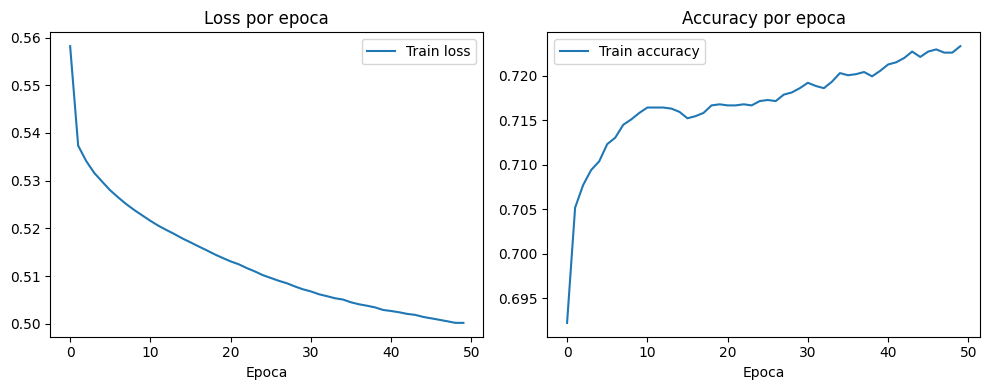

In [140]:
# Grafica de curva de entrenamiento
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train loss')
plt.title('Loss por epoca')
plt.xlabel('Epoca')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.title('Accuracy por epoca')
plt.xlabel('Epoca')
plt.legend()

plt.tight_layout()
plt.show()

Se puede observar que el loss por epoca va disminuyendo lo que puede entenderse como primer insight que el modelo va mejorando con cada epoca

## Evaluación inicial del modelo

Para la evaluacion, por cuestion de simplicidad usare skitlearn que ya te da un report de manera directa con las metricas que necesito: precision, recall y f1-score. Estas métricas son ampliamente adoptadas en la literatura de
credit risk. Chang et al. (2024) emplean este mismo conjunto de métricas
para comparar modelos de clasificación de riesgo crediticio incluyendo
redes neuronales, regresión logística y modelos de boosting, concluyendo
que constituyen el estándar para evaluar la eficiencia de algoritmos en
este dominio

In [141]:
y_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_prob >= 0.5).astype(int)

report_model_v1 = classification_report(y_test_arr, y_pred, target_names=['Paid (0)', 'Default (1)'])
print(report_model_v1)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    Paid (0)       0.70      0.89      0.78      1230
 Default (1)       0.73      0.43      0.54       839

    accuracy                           0.71      2069
   macro avg       0.72      0.66      0.66      2069
weighted avg       0.71      0.71      0.68      2069



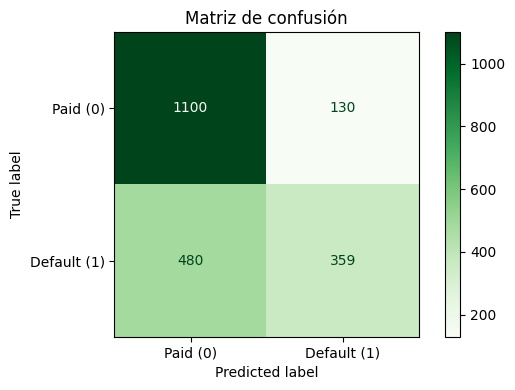

In [142]:
fig, ax = plt.subplots(figsize=(6, 4))

# Matriz de confusion
cm = confusion_matrix(y_test_arr, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Paid (0)', 'Default (1)']).plot(ax=ax, cmap='Greens')
ax.set_title('Matriz de confusión')

plt.tight_layout()
plt.show()

## Refinamiento

### Modelo Version 2 (Refinado)

El primer ajuste es penalizar ajustes en las clases debido a que modelo ve 8,276 ejemplos de mi set de entrenamiento, donde aproximadamente el 60% son pagos y el 40% son defaults. Aprende que a siempre predecir Paid. El resultado es que no detecta muy bien defaults (como se muestra en la matriz de confusion del modelo v1)

Como hay más Paid, aprende a favorecerlos.

In [151]:
n_total = len(y_train_arr)
n_paid = (y_train_arr == 0).sum()
n_default = (y_train_arr == 1).sum()

class_weight = {
    0: n_total / (2 * n_paid),
    1: n_total / (2 * n_default)
}
print(f"Class weights: {class_weight}")

Class weights: {0: np.float64(0.8153694581280788), 1: np.float64(1.2927210246797876)}


La idea es que despues de esto el modelo empiece a tomarse más en serio los defaults porque fallar en uno le duele más. Cambia el costo de equivocarse por clase.

Al equivocarse en un Paid cuesta 0.82 debido a que es la clase mayoritaria, se penaliza menos. Mientras que equivocarse en un Default cuesta 1.27 debido a que es la clase minoritaria, la idea es que se penalice más

In [177]:
tf.random.set_seed(42)

model_v2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    tf.keras.layers.Dense(64, activation='relu'),
    #tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    #tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,685 (30.02 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,124 (20.02 KB)

Se agrega la tecnica de **early stopping** que se detiene si no mejora en 10 epocas seguidas. Prechelt (2012) establece que detener el entrenamiento en el momento
adecuado evita que el modelo memorice los datos de entrenamiento y
pierda capacidad de predecir correctamente datos nuevos

In [178]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_v2 = model_v2.fit(
    X_train_scaled, y_train_arr,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6447 - loss: 0.5729 - val_accuracy: 0.6208 - val_loss: 0.5705
Epoch 2/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6367 - loss: 0.5536 - val_accuracy: 0.6268 - val_loss: 0.5618
Epoch 3/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6352 - loss: 0.5493 - val_accuracy: 0.6268 - val_loss: 0.5566
Epoch 4/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6386 - loss: 0.5461 - val_accuracy: 0.6268 - val_loss: 0.5537
Epoch 5/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6395 - loss: 0.5435 - val_accuracy: 0.6268 - val_loss: 0.5509
Epoch 6/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6392 - loss: 0.5414 - val_accuracy: 0.6329 - val_loss: 0.5489
Epoch 7/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6414 - loss: 0.5393 - val_accuracy: 0.6304 - val_loss: 0.5470
Epoch 8/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6423 - loss: 0.5374 - val_accu

In [179]:
# Metricas modelo v2
y_prob_v2 = model_v2.predict(X_test_scaled).flatten()
y_pred_v2 = (y_prob_v2 >= 0.5).astype(int)

print(classification_report(y_test_arr, y_pred_v2, target_names=['Paid (0)', 'Default (1)']))

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    Paid (0)       0.77      0.56      0.65      1230
 Default (1)       0.54      0.76      0.63       839

    accuracy                           0.64      2069
   macro avg       0.66      0.66      0.64      2069
weighted avg       0.68      0.64      0.64      2069



In [180]:
print(report_model_v1)

              precision    recall  f1-score   support

    Paid (0)       0.70      0.89      0.78      1230
 Default (1)       0.73      0.43      0.54       839

    accuracy                           0.71      2069
   macro avg       0.72      0.66      0.66      2069
weighted avg       0.71      0.71      0.68      2069



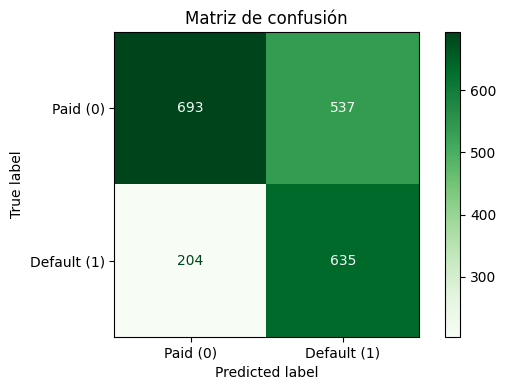

In [181]:
fig, ax = plt.subplots(figsize=(6, 4))

# Matriz de confusion v2
cm_v2 = confusion_matrix(y_test_arr, y_pred_v2)
disp_v2 = ConfusionMatrixDisplay(cm_v2, display_labels=['Paid (0)', 'Default (1)']).plot(ax=ax, cmap='Greens')
ax.set_title('Matriz de confusión')

plt.tight_layout()
plt.show()

## Guardar el modelo para usarlo

In [175]:
model_v2.save('/content/drive/MyDrive/Colab Notebooks/CS AVANZADAS/Modulo Inteligencia Artificial/Proyecto/bnpl_model_v2.keras')

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [176]:
# Guardar escalamiento
np.save('/content/drive/MyDrive/Colab Notebooks/CS AVANZADAS/Modulo Inteligencia Artificial/Proyecto/mean.npy', mean)
np.save('/content/drive/MyDrive/Colab Notebooks/CS AVANZADAS/Modulo Inteligencia Artificial/Proyecto/std.npy', std)